# Open in Colab
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH09/ch09_agentvista.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
#@title  Clone AgentVista and install dependencies
!git clone https://github.com/Nicolepcx/AgentVista.git
%cd AgentVista

!pip -q install --upgrade pip setuptools wheel
!pip -q install -r requirements.txt
!pip -q install huggingface_hub pyarrow pillow

Cloning into 'AgentVista'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 92 (delta 28), reused 79 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (92/92), 3.00 MiB | 13.18 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/AgentVista
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyprojec

In [ ]:
# @title Download AgentVista dataset from Hugging Face
import os
from huggingface_hub import snapshot_download

DATASET_DIR = "/content/datasets"

snapshot_download(
    repo_id="Warrieryes/AgentVista",
    repo_type="dataset",
    local_dir=DATASET_DIR,
    local_dir_use_symlinks=False,
)

print("Dataset downloaded to:", DATASET_DIR)
print("Top level files:", os.listdir(DATASET_DIR)[:20])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/294M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

Dataset downloaded to: /content/datasets
Top level files: ['.cache', '.gitattributes', 'data', 'README.md']


In [ ]:
# @title Enter API keys
import os
from getpass import getpass

# Harness LLM judge (AgentVista accuracy_score): after inference, compares model output to ground truth.
# Required env vars (see AgentVista-main/utils/general_qa_tool.py):
#   VERIFIER_API_KEY   — same OpenRouter key is fine (set below).
#   VERIFIER_END_POINT — OpenRouter chat-completions URL (set below; also set again in the next cell).
#   VERIFIER_MODEL_NAME — optional; defaults to gpt-4o in the harness if unset; we set an OpenRouter slug below.
OPENROUTER_CHAT = "https://openrouter.ai/api/v1/chat/completions"
os.environ["REASONING_END_POINT"] = OPENROUTER_CHAT
os.environ["VERIFIER_END_POINT"] = OPENROUTER_CHAT
# Cheap, text-only judge on OpenRouter (change if you prefer e.g. openai/gpt-4.1)
os.environ["VERIFIER_MODEL_NAME"] = os.environ.get("VERIFIER_MODEL_NAME", "gpt-5.4-mini")

os.environ["REASONING_API_KEY"] = getpass("OpenRouter API key: ")
os.environ["SERPAPI_KEY"] = getpass("Serper API key: ")

jina_key = getpass("Jina API key (press Enter to skip): ")
os.environ["JINA_API_KEY"] = jina_key if jina_key.strip() else ""

verifier_key = getpass("Verifier API key via OpenRouter (press Enter to reuse reasoning key): ")
os.environ["VERIFIER_API_KEY"] = verifier_key if verifier_key.strip() else os.environ["REASONING_API_KEY"]

print("Keys set.")
print("Harness judge: VERIFIER_END_POINT =", os.environ["VERIFIER_END_POINT"])
print("Harness judge: VERIFIER_MODEL_NAME =", os.environ["VERIFIER_MODEL_NAME"])

OpenRouter API key: ··········
Serper API key: ··········
Jina API key (press Enter to skip): ··········
Verifier API key via OpenRouter (press Enter to reuse reasoning key): ··········
Keys set.
Harness judge: VERIFIER_END_POINT = https://openrouter.ai/api/v1/chat/completions
Harness judge: VERIFIER_MODEL_NAME = gpt-5.4-mini


In [ ]:
# @title Configure OpenRouter for multi model evaluation
import os

OPENROUTER_ENDPOINT = "https://openrouter.ai/api/v1/chat/completions"

MODELS = [
    "openai/gpt-5.4",
    "qwen/qwen3.5-35b-a3b",
    "google/gemini-3.1-pro-preview",
]

os.environ["REASONING_END_POINT"] = OPENROUTER_ENDPOINT
os.environ["VERIFIER_END_POINT"] = OPENROUTER_ENDPOINT
# If you skipped cell 3, still pick a judge model for OpenRouter (text-only scoring).
os.environ.setdefault("VERIFIER_MODEL_NAME", "openai/gpt-5.4-mini")
os.environ["ENABLED_TOOLS"] = "web_search,image_search,visit,code_interpreter"

print("OpenRouter endpoint:", OPENROUTER_ENDPOINT)
print("Harness judge model (VERIFIER_MODEL_NAME):", os.environ.get("VERIFIER_MODEL_NAME"))
print("Enabled tools:", os.environ["ENABLED_TOOLS"])
print("\nModels selected for comparison:")
for m in MODELS:
    print(" ", m)

OpenRouter endpoint: https://openrouter.ai/api/v1/chat/completions
Harness judge model (VERIFIER_MODEL_NAME): gpt-5.4-mini
Enabled tools: web_search,image_search,visit,code_interpreter

Models selected for comparison:
  openai/gpt-5.4
  qwen/qwen3.5-35b-a3b
  google/gemini-3.1-pro-preview


In [ ]:
# @title Load parquet dataset and export embedded images safely
import os
import io
import json
import pandas as pd
import numpy as np
from glob import glob
from PIL import Image

DATASET_DIR = "/content/datasets"
EXPORT_DIR = os.path.join(DATASET_DIR, "exported_images")
os.makedirs(EXPORT_DIR, exist_ok=True)

parquet_files = glob(os.path.join(DATASET_DIR, "**", "*.parquet"), recursive=True)

if not parquet_files:
    raise FileNotFoundError("No parquet files found in dataset directory.")

print("Found parquet files:", parquet_files)

dfs = [pd.read_parquet(p) for p in parquet_files]
df = pd.concat(dfs, ignore_index=True)

print("Total samples loaded:", len(df))
print("Columns:", df.columns.tolist())


def unwrap_object(x):
    """
    Recursively unwrap numpy object arrays, singleton tuples, and nested containers.
    """
    while True:
        if isinstance(x, np.ndarray):
            if x.dtype == object:
                if x.size == 1:
                    x = x.item()
                    continue
                return x.tolist()
            return x

        if isinstance(x, tuple):
            if len(x) == 1:
                x = x[0]
                continue
            return list(x)

        if isinstance(x, list):
            if len(x) == 1 and not isinstance(x[0], (str, bytes, bytearray, dict)):
                x = x[0]
                continue
            return x

        return x


def save_one_image(img_obj, out_path_base):
    """
    Save one image object to disk and return its absolute path.
    Supports bytes, dicts, PIL images, and numeric numpy arrays.
    """
    img_obj = unwrap_object(img_obj)

    if isinstance(img_obj, (bytes, bytearray)):
        img = Image.open(io.BytesIO(img_obj)).convert("RGB")
        out_path = f"{out_path_base}.png"
        img.save(out_path)
        return out_path

    if isinstance(img_obj, dict):
        if "bytes" in img_obj and img_obj["bytes"] is not None:
            img = Image.open(io.BytesIO(img_obj["bytes"])).convert("RGB")
            out_path = f"{out_path_base}.png"
            img.save(out_path)
            return out_path
        if "path" in img_obj and img_obj["path"]:
            return img_obj["path"]

    if isinstance(img_obj, Image.Image):
        out_path = f"{out_path_base}.png"
        img_obj.convert("RGB").save(out_path)
        return out_path

    if isinstance(img_obj, np.ndarray):
        if img_obj.dtype == object:
            raise TypeError(f"Still received object ndarray after unwrap: shape={img_obj.shape}")
        img = Image.fromarray(img_obj)
        out_path = f"{out_path_base}.png"
        img.save(out_path)
        return out_path

    raise TypeError(f"Unsupported image object type after unwrap: {type(img_obj)}")


def normalize_images(images_field, sample_idx):
    """
    Convert the parquet images field into a list of relative image paths.
    """
    images_field = unwrap_object(images_field)

    if isinstance(images_field, (bytes, bytearray, dict, Image.Image, np.ndarray)):
        images_field = [images_field]

    if isinstance(images_field, tuple):
        images_field = list(images_field)

    if not isinstance(images_field, list):
        raise TypeError(f"Unexpected images field type: {type(images_field)}")

    rel_paths = []
    for j, img_obj in enumerate(images_field):
        out_base = os.path.join(EXPORT_DIR, f"sample_{sample_idx}_img_{j}")
        saved_path = save_one_image(img_obj, out_base)
        rel_path = os.path.relpath(saved_path, DATASET_DIR)
        rel_paths.append(rel_path)

    return rel_paths


print("\nExample domains:")
print(sorted(df["domain"].dropna().unique().tolist()))

Found parquet files: ['/content/datasets/data/train-00000-of-00002.parquet', '/content/datasets/data/train-00001-of-00002.parquet']
Total samples loaded: 209
Columns: ['images', 'problem', 'answer', 'domain', 'subdomain']

Example domains:
['academics', 'commerce', 'culture', 'entertainment', 'geography', 'society', 'technology']


In [ ]:
# @title Create a stratified AgentVista subset for side by side model comparison
import os
import json

DOMAINS = [
    "commerce",
    "entertainment",
    "technology",
]

SAMPLES_PER_DOMAIN = 5
STRATIFIED_VAL_PATH = os.path.join(DATASET_DIR, "val_domain_smoke_test.json")

subset = []
sample_counter = 0

for domain in DOMAINS:
    domain_df = df[df["domain"] == domain].copy()
    if len(domain_df) == 0:
        continue

    take = min(SAMPLES_PER_DOMAIN, len(domain_df))
    sampled = domain_df.sample(n=take, random_state=42)

    for _, row in sampled.iterrows():
        image_paths = normalize_images(row["images"], sample_counter)

        subset.append({
            "question_id": f"sample_{sample_counter}",
            "question": row["problem"],
            "problem": row["problem"],
            "images": image_paths,
            "solution": row["answer"],
            "answer": row["answer"],
            "domain": row["domain"],
            "subdomain": row["subdomain"],
        })
        sample_counter += 1

with open(STRATIFIED_VAL_PATH, "w", encoding="utf-8") as f:
    json.dump(subset, f, ensure_ascii=False, indent=2)

print("Saved stratified subset to:", STRATIFIED_VAL_PATH)
print("Number of samples:", len(subset))
print("Domains included:", sorted(set(x["domain"] for x in subset)))
print("\nFirst sample preview:")
print(json.dumps(subset[0], indent=2, ensure_ascii=False)[:1500])

Saved stratified subset to: /content/datasets/val_domain_smoke_test.json
Number of samples: 15
Domains included: ['commerce', 'entertainment', 'technology']

First sample preview:
{
  "question_id": "sample_0",
  "question": "<image>\nIt is now October 2025, and I need to rent office space for a team of 5 employees, and the space must meet the requirements in the local workplace safety regulations regarding the minimum area per employee. Considering the current market rental levels and typical utility costs in this area, which room number has the lowest total monthly cost (rent plus utilities) while meeting the legal space requirements for 5 employees?",
  "problem": "<image>\nIt is now October 2025, and I need to rent office space for a team of 5 employees, and the space must meet the requirements in the local workplace safety regulations regarding the minimum area per employee. Considering the current market rental levels and typical utility costs in this area, which room number has 

Loaded subset records: 15
Schema check passed for first 5 samples.
Total exported images checked: 18
Missing images: 0
Unreadable images: 0

Image validation passed.


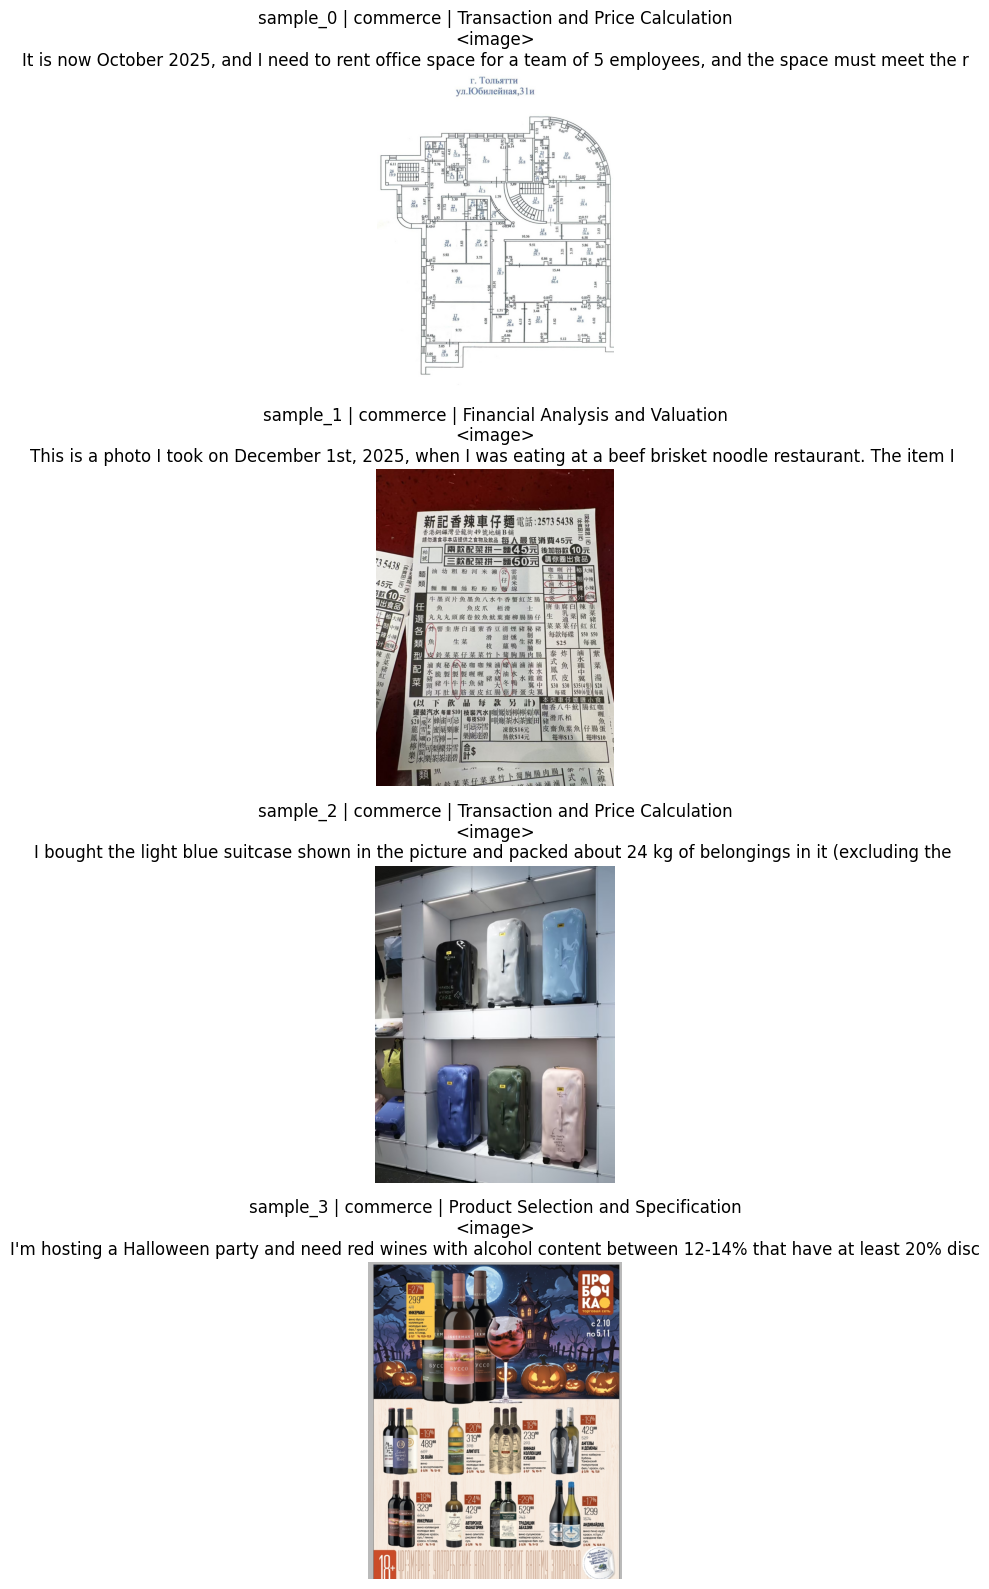

In [ ]:
# @title Validate subset structure and exported images
import os
import json
from PIL import Image
import matplotlib.pyplot as plt

with open(STRATIFIED_VAL_PATH, "r", encoding="utf-8") as f:
    subset_records = json.load(f)

print("Loaded subset records:", len(subset_records))

required_fields = ["question_id", "question", "images", "answer", "domain", "subdomain"]
for i, rec in enumerate(subset_records[:5]):
    missing = [k for k in required_fields if k not in rec]
    if missing:
        raise ValueError(f"Sample {i} is missing required fields: {missing}")

print("Schema check passed for first 5 samples.")

missing_images = []
bad_images = []
image_summary = []

for rec in subset_records:
    qid = rec["question_id"]
    for img_rel in rec["images"]:
        img_abs = os.path.join(DATASET_DIR, img_rel)

        if not os.path.exists(img_abs):
            missing_images.append((qid, img_rel))
            continue

        try:
            with Image.open(img_abs) as img:
                width, height = img.size
                image_summary.append({
                    "question_id": qid,
                    "image": img_rel,
                    "format": img.format,
                    "mode": img.mode,
                    "width": width,
                    "height": height,
                })
        except Exception as e:
            bad_images.append((qid, img_rel, str(e)))

print("Total exported images checked:", len(image_summary))
print("Missing images:", len(missing_images))
print("Unreadable images:", len(bad_images))

if missing_images[:5]:
    print("\nExample missing images:")
    for x in missing_images[:5]:
        print(x)

if bad_images[:5]:
    print("\nExample unreadable images:")
    for x in bad_images[:5]:
        print(x)

if missing_images or bad_images:
    raise ValueError("Image validation failed. Fix paths or exports before continuing.")

print("\nImage validation passed.")

# Show a few examples visually
n_show = min(4, len(subset_records))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 4 * n_show))
if n_show == 1:
    axes = [axes]

for ax, rec in zip(axes, subset_records[:n_show]):
    first_img = rec["images"][0]
    img_path = os.path.join(DATASET_DIR, first_img)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f'{rec["question_id"]} | {rec["domain"]} | {rec["subdomain"]}\n{rec["question"][:120]}')
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# @title Tiny sanity check on 2 samples with one model before the full run
import os
import json
import subprocess

SANITY_PATH = os.path.join(DATASET_DIR, "val_sanity_check.json")

with open(STRATIFIED_VAL_PATH, "r", encoding="utf-8") as f:
    full_subset = json.load(f)

sanity_subset = full_subset[:2]

with open(SANITY_PATH, "w", encoding="utf-8") as f:
    json.dump(sanity_subset, f, ensure_ascii=False, indent=2)

sanity_model = MODELS[0]
sanity_output_dir = "/content/agentvista_sanity_run"

os.makedirs(sanity_output_dir, exist_ok=True)

env = os.environ.copy()
env["REASONING_MODEL_NAME"] = sanity_model
env["VERIFIER_MODEL_NAME"] = sanity_model

cmd = [
    "python", "infer.py",
    "--input-file", SANITY_PATH,
    "--image-folder", DATASET_DIR,
    "--output-dir", sanity_output_dir,
    "--max-turns", "8",
    "--max-images", "10",
    "--max-total-tokens", "16000",
    "--skip-completed",
]

print("Running sanity check model:", sanity_model)
result = subprocess.run(cmd, env=env, text=True, capture_output=True)

print(result.stdout[-4000:])
if result.returncode != 0:
    print("\nError output:")
    print(result.stderr[-4000:])

Running sanity check model: openai/gpt-5.4
ck
[Visit] Fallback to Jina API after other methods failed...
[Visit] Jina API request failed (attempt 1/3): HTTPSConnectionPool(host='r.jina.ai', port=443): Read timed out. (read timeout=20)
[Visit] Jina API request failed (attempt 2/3): HTTPSConnectionPool(host='r.jina.ai', port=443): Read timed out. (read timeout=20)
[Visit] Jina API request failed (attempt 3/3): HTTPSConnectionPool(host='r.jina.ai', port=443): Read timed out. (read timeout=20)
[Image Processing] Skipping image extraction for visit (returns text summary, images should not be extracted)
[API] No fallback API configured, using primary API with 2 retries
[Primary API] API Request attempt 1:
Model: openai/gpt-5.4
Messages count: 10
Temperature: 0.0
  Message 0: role=system, content_preview=You are a visual reasoning agent. Your goal is to answer questions about images.

# AVAILABLE TOOLS:...
  Message 1: role=user, content_preview=[{'type': 'image_url', 'image_url': {'url': 'da

In [ ]:
# @title Inspect sanity check predictions before full evaluation
import os
import json
import pandas as pd

sanity_results_path = "/content/agentvista_sanity_run/results.jsonl"

sanity_rows = []
if os.path.exists(sanity_results_path):
    with open(sanity_results_path, "r", encoding="utf-8") as f:
        for line in f:
            sanity_rows.append(json.loads(line))

sanity_df = pd.DataFrame(sanity_rows)
print("Sanity result columns:", sanity_df.columns.tolist())

cols = [c for c in ["question_id", "final_answer", "ground_truth", "reasoning_text"] if c in sanity_df.columns]
display(sanity_df[cols].head(10))

Sanity result columns: ['question_id', 'prompt', 'final_answer', 'ground_truth', 'conversation_history', 'accuracy_score', 'trajectory_text', 'trajectory_score', 'trajectory_analysis']


,question_id,final_answer,ground_truth
0,sample_0,Room **28** is the cheapest compliant choice.\...,Room 28
1,sample_1,你一共支付了 **約 54.49 元人民幣**（60 港幣 × 2025年12月1日匯率 1...,54.6


In [ ]:
# @title Inspect sanity predictions in detail
import pandas as pd
import json
import os

sanity_results_path = "/content/agentvista_sanity_run/results.jsonl"

rows = []
with open(sanity_results_path, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

sanity_df = pd.DataFrame(rows)
display(sanity_df[["question_id", "prompt", "final_answer", "ground_truth", "accuracy_score"]])

,question_id,prompt,final_answer,ground_truth,accuracy_score
0,sample_0,"It is now October 2025, and I need to rent off...",Room **28** is the cheapest compliant choice.\...,Room 28,1.0
1,sample_1,"This is a photo I took on December 1st, 2025, ...",你一共支付了 **約 54.49 元人民幣**（60 港幣 × 2025年12月1日匯率 1...,54.6,0.0


In [ ]:
# @title Run AgentVista on the same subset for all selected models
import os
import subprocess

INPUT_FILE = STRATIFIED_VAL_PATH
IMAGE_FOLDER = DATASET_DIR
BASE_OUTPUT_DIR = "/content/agentvista_multi_model_runs"

os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

for model_name in MODELS:
    safe_name = model_name.replace("/", "__")
    output_dir = os.path.join(BASE_OUTPUT_DIR, safe_name)
    os.makedirs(output_dir, exist_ok=True)

    env = os.environ.copy()
    env["REASONING_MODEL_NAME"] = model_name
    env["VERIFIER_MODEL_NAME"] = model_name

    cmd = [
        "python", "infer.py",
        "--input-file", INPUT_FILE,
        "--image-folder", IMAGE_FOLDER,
        "--output-dir", output_dir,
        "--max-turns", "10",
        "--max-images", "20",
        "--max-total-tokens", "24000",
        "--skip-completed",
    ]

    print("\nRunning model:", model_name)
    print("Output directory:", output_dir)

    result = subprocess.run(cmd, env=env, text=True, capture_output=True)

    print(result.stdout[-3000:])
    if result.returncode != 0:
        print("\nError output:")
        print(result.stderr[-3000:])


Running model: openai/gpt-5.4
Output directory: /content/agentvista_multi_model_runs/openai__gpt-5.4
he chart (likely dots.vlm1) and identify benchmark comparison details for OCR, Document, and Chart tasks versus Gemini 2.5 Pro; specifically which benchmark names show the open-source model outperforming Gemini 2.5 Pro.'}
[Tool Cache] Created new instance of visit
[Visit] Fetching URL: https://huggingface.co/spaces/opencompass/open_vlm_leaderboard
[Visit] Goal: Find the top open-source model in the chart (likely dots.vlm1) and identify benchmark comparison details for OCR, Document, and Chart tasks versus Gemini 2.5 Pro; specifically which benchmark names show the open-source model outperforming Gemini 2.5 Pro.
[Visit] Trying Jina API first...
[Visit] Jina API extraction successful: 1044 characters
[Visit] Extracted 1044 characters
[Visit] Calling API to summarize content (model: openai/gpt-5.4)...
[Visit] API summarization successful (evidence: 661 chars, summary: 361 chars)
[Image Pr

In [ ]:
# @title Load and merge outputs from all models
import os
import json
import pandas as pd

all_rows = []

for model_name in MODELS:
    safe_name = model_name.replace("/", "__")
    results_path = os.path.join(BASE_OUTPUT_DIR, safe_name, "results.jsonl")

    if not os.path.exists(results_path):
        print("Missing results for:", model_name)
        continue

    with open(results_path, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            row["model"] = model_name
            all_rows.append(row)

results_df = pd.DataFrame(all_rows)

print("Loaded rows:", len(results_df))
print("Columns:", results_df.columns.tolist())
display(results_df.head(10))

Loaded rows: 45
Columns: ['question_id', 'prompt', 'final_answer', 'ground_truth', 'conversation_history', 'accuracy_score', 'trajectory_text', 'trajectory_score', 'trajectory_analysis', 'model']


,question_id,prompt,final_answer,ground_truth,conversation_history,accuracy_score,trajectory_text,trajectory_score,trajectory_analysis,model
0,sample_0,"It is now October 2025, and I need to rent off...",Assuming the standard office workplace rule st...,Room 28,"[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,"the ground truth answer is room 28, but the mo...",openai/gpt-5.4
1,sample_1,"This is a photo I took on December 1st, 2025, ...",你一共付了 **60港币**。 \n按 **2025年12月1日** 约 **1 港币 =...,54.6,"[{'role': 'system', 'content': 'You are a visu...",1.0,**system**: You are a visual reasoning agent. ...,1.0,the predicted answer computes a total of about...,openai/gpt-5.4
2,sample_2,I bought the light blue suitcase shown in the ...,You would most likely need to pay **210 RMB** ...,690RMB,"[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,"the ground truth is 690 rmb, but the model pre...",openai/gpt-5.4
3,sample_3,I'm hosting a Halloween party and need red win...,The wine that best matches your criteria is **...,Традиции Абхазии (Traditsii Abkhazii)， 6.82,"[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,the predicted answer identifies the correct wi...,openai/gpt-5.4
4,sample_4,I took this photo at a really cool pop-up stor...,The pop-up appears to be the **MINISO x Disney...,"29 days (November 29th to December 28th, 2025)","[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,the predicted answer matches the start and end...,openai/gpt-5.4
5,sample_5,How many individual shooting zone units are th...,31,58,"[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,"the ground truth answer is 58, while the model...",openai/gpt-5.4
6,sample_6,"Please observe this group of images, whose bac...","1, 3, 4, 6","2, 3, 6","[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,"the ground truth serial numbers are 2, 3, 6, b...",openai/gpt-5.4
7,sample_7,I've been tracking this player count graph bec...,The game is **Monster Hunter Wilds**.\n\nUsing...,Monster Hunter Wilds; 59.86%,"[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,the model correctly identified the game as mon...,openai/gpt-5.4
8,sample_8,I want to know the best finishing position tha...,2nd place,3,"[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,the ground truth says the best finishing posit...,openai/gpt-5.4
9,sample_9,Please tell me the names of the current first-...,I can’t tell the swimmers’ names from this ima...,First-place: Ryan Held\nLast-place: Drew Kibler,"[{'role': 'system', 'content': 'You are a visu...",0.0,**system**: You are a visual reasoning agent. ...,0.0,the prediction does not provide the swimmers’ ...,openai/gpt-5.4


In [ ]:
# @title Standardize result fields, recover domain, and compute correctness
import os
import json
import re
import pandas as pd

def find_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

pred_col = find_first_existing(results_df, [
    "prediction", "pred", "model_answer", "final_answer", "response"
])

gold_col = find_first_existing(results_df, [
    "solution", "answer", "ground_truth", "gold_answer"
])

qid_col = find_first_existing(results_df, [
    "question_id", "doc_id", "id"
])

domain_col = find_first_existing(results_df, [
    "domain"
])

# Harness column names that may hold LLM-judge scores (AgentVista: accuracy_score).
# Populated only when VERIFIER_API_KEY and VERIFIER_END_POINT are set (VERIFIER_MODEL_NAME
# selects the judge on OpenRouter; see cells 3–4). See AgentVista-main/README.md.
# Without API key + endpoint, harness accuracy_score stays 0 for every row.
score_col = find_first_existing(results_df, [
    "accuracy_score", "score", "is_correct", "correct", "accuracy"
])

verifier_configured = bool(
    os.environ.get("VERIFIER_API_KEY") and os.environ.get("VERIFIER_END_POINT")
)

print("Prediction column:", pred_col)
print("Gold column:", gold_col)
print("Question id column:", qid_col)
print("Domain column from results:", domain_col)
print("Score column:", score_col)

if pred_col is None:
    raise ValueError("Could not find a prediction column in results.jsonl.")

if gold_col is None:
    raise ValueError("Could not find a ground truth column in results.jsonl.")

if qid_col is None:
    raise ValueError("Could not find a question id column in results.jsonl.")


def normalize_text(x):
    if x is None:
        return ""
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x


with open(STRATIFIED_VAL_PATH, "r", encoding="utf-8") as f:
    subset_records = json.load(f)

subset_meta = pd.DataFrame(subset_records)[["question_id", "domain", "subdomain", "question"]]

if domain_col is None:
    results_df = results_df.merge(
        subset_meta,
        left_on=qid_col,
        right_on="question_id",
        how="left"
    )
    domain_col = "domain"

results_df["pred_norm"] = results_df[pred_col].apply(normalize_text)
results_df["gold_norm"] = results_df[gold_col].apply(normalize_text)

results_df["accuracy_binary_exact"] = (
    results_df["pred_norm"] == results_df["gold_norm"]
).astype(float)

if verifier_configured and score_col is not None:
    results_df["accuracy_binary"] = results_df[score_col].astype(float)
    print(
        "Using harness accuracy_score (verifier configured). "
        "Column accuracy_binary_exact is normalized string exact match for comparison."
    )
else:
    results_df["accuracy_binary"] = results_df["accuracy_binary_exact"]
    if score_col is not None and not verifier_configured:
        print(
            "Verifier env vars not set; accuracy_binary uses normalized exact match "
            "(raw harness accuracy_score is 0 without VERIFIER_API_KEY / VERIFIER_END_POINT)."
        )

# Optional relaxed diagnostic metric
results_df["contains_match"] = results_df.apply(
    lambda r: float(
        r["gold_norm"] in r["pred_norm"] or r["pred_norm"] in r["gold_norm"]
        if r["pred_norm"] and r["gold_norm"] else 0.0
    ),
    axis=1
)

print("\nColumns after recovery:")
print(results_df.columns.tolist())

display(
    results_df[
        [
            c
            for c in [
                qid_col,
                "model",
                domain_col,
                pred_col,
                gold_col,
                "accuracy_binary",
                "accuracy_binary_exact",
                "contains_match",
            ]
            if c in results_df.columns
        ]
    ].head(20)
)

Prediction column: final_answer
Gold column: ground_truth
Question id column: question_id
Domain column from results: None
Score column: accuracy_score
Using harness accuracy_score (verifier configured). Column accuracy_binary_exact is normalized string exact match for comparison.

Columns after recovery:
['question_id', 'prompt', 'final_answer', 'ground_truth', 'conversation_history', 'accuracy_score', 'trajectory_text', 'trajectory_score', 'trajectory_analysis', 'model', 'domain', 'subdomain', 'question', 'pred_norm', 'gold_norm', 'accuracy_binary_exact', 'accuracy_binary', 'contains_match']


,question_id,model,domain,final_answer,ground_truth,accuracy_binary,accuracy_binary_exact,contains_match
0,sample_0,openai/gpt-5.4,commerce,Assuming the standard office workplace rule st...,Room 28,0.0,0.0,0.0
1,sample_1,openai/gpt-5.4,commerce,你一共付了 **60港币**。 \n按 **2025年12月1日** 约 **1 港币 =...,54.6,1.0,0.0,0.0
2,sample_2,openai/gpt-5.4,commerce,You would most likely need to pay **210 RMB** ...,690RMB,0.0,0.0,0.0
3,sample_3,openai/gpt-5.4,commerce,The wine that best matches your criteria is **...,Традиции Абхазии (Traditsii Abkhazii)， 6.82,0.0,0.0,0.0
4,sample_4,openai/gpt-5.4,commerce,The pop-up appears to be the **MINISO x Disney...,"29 days (November 29th to December 28th, 2025)",0.0,0.0,0.0
5,sample_5,openai/gpt-5.4,entertainment,31,58,0.0,0.0,0.0
6,sample_6,openai/gpt-5.4,entertainment,"1, 3, 4, 6","2, 3, 6",0.0,0.0,0.0
7,sample_7,openai/gpt-5.4,entertainment,The game is **Monster Hunter Wilds**.\n\nUsing...,Monster Hunter Wilds; 59.86%,0.0,0.0,0.0
8,sample_8,openai/gpt-5.4,entertainment,2nd place,3,0.0,0.0,0.0
9,sample_9,openai/gpt-5.4,entertainment,I can’t tell the swimmers’ names from this ima...,First-place: Ryan Held\nLast-place: Drew Kibler,0.0,0.0,0.0


In [ ]:
# @title Build a side by side comparison table
compare_cols = [c for c in [qid_col, domain_col, gold_col, pred_col] if c in results_df.columns]
sample_view = results_df[["model", "accuracy_binary"] + compare_cols].copy()

pivot_values = ["accuracy_binary"]
if pred_col is not None:
    pivot_values.append(pred_col)

wide_df = sample_view.pivot_table(
    index=[c for c in [qid_col, domain_col, gold_col] if c in sample_view.columns],
    columns="model",
    values=pivot_values,
    aggfunc="first"
).reset_index()

display(wide_df.head(20))

question_id         domain  \
model                              
0        sample_0       commerce   
1        sample_1       commerce   
2       sample_10     technology   
3       sample_11     technology   
4       sample_12     technology   
5       sample_13     technology   
6       sample_14     technology   
7        sample_2       commerce   
8        sample_3       commerce   
9        sample_4       commerce   
10       sample_5  entertainment   
11       sample_6  entertainment   
12       sample_7  entertainment   
13       sample_8  entertainment   
14       sample_9  entertainment   

                                            ground_truth  \
model                                                      
0                                                Room 28   
1                                                   54.6   
2                                   Qwen2‑VL‑7B‑Instruct   
3      Micro-vibration and adhesive wear; they degrad...   
4                                          1, 3, 2, 4, R   
5                               23 (or beteen 22 and 24)   
6                           charxiv(dq), DOCVQA, ChartQA   
7                                                 690RMB   
8            Традиции Абхазии (Traditsii Abkhazii)， 6.82   
9         29 days (November 29th to December 28th, 2025)   
10                                                    58   
11                                               2, 3, 6   
12                          Monster Hunter Wilds; 59.86%   
13                                                     3   
14       First-place: Ryan Held\nLast-place: Drew Kibler   

                    accuracy_binary                                      \
model google/gemini-3.1-pro-preview openai/gpt-5.4 qwen/qwen3.5-35b-a3b   
0                               0.0            0.0                  0.0   
1                               0.0            1.0                  0.0   
2                               0.0            0.0                  0.0   
3                               0.0            0.0                  0.0   
4                               0.0            1.0                  1.0   
5                               0.0            0.0                  0.0   
6                               0.0            0.0                  0.0   
7                               0.0            0.0                  0.0   
8                               0.0            0.0                  0.0   
9                               0.0            0.0                  0.0   
10                              0.0            0.0                  0.0   
11                              0.0            0.0                  0.0   
12                              0.0            0.0                  0.0   
13                              0.0            0.0                  0.0   
14                              0.0            0.0                  0.0   

                                            final_answer  \
model                      google/gemini-3.1-pro-preview   
0      Error: Reached max turns without a definitive ...   
1                                                  54.48   
2                                   llava-v1.6-vicuna-7b   
3      Error: Reached max turns without a definitive ...   
4      Error: Reached max turns without a definitive ...   
5                                                      1   
6      tags.\nDone.\nI will just write the thought pr...   
7      Error: Reached max turns without a definitive ...   
8      The wine that meets your criteria with the hig...   
9                                                     30   
10                Error: Could not parse model response.   
11                                            3, 4, 5, 6   
12     Error: Reached max turns without a definitive ...   
13     Error: Reached max turns without a definitive ...   
14                Error: Could not parse model response.   

                                                          \
model          

model,google/gemini-3.1-pro-preview,openai/gpt-5.4,qwen/qwen3.5-35b-a3b
domain,,,
commerce,0.0,0.2,0.0
entertainment,0.0,0.0,0.0
technology,0.0,0.2,0.2


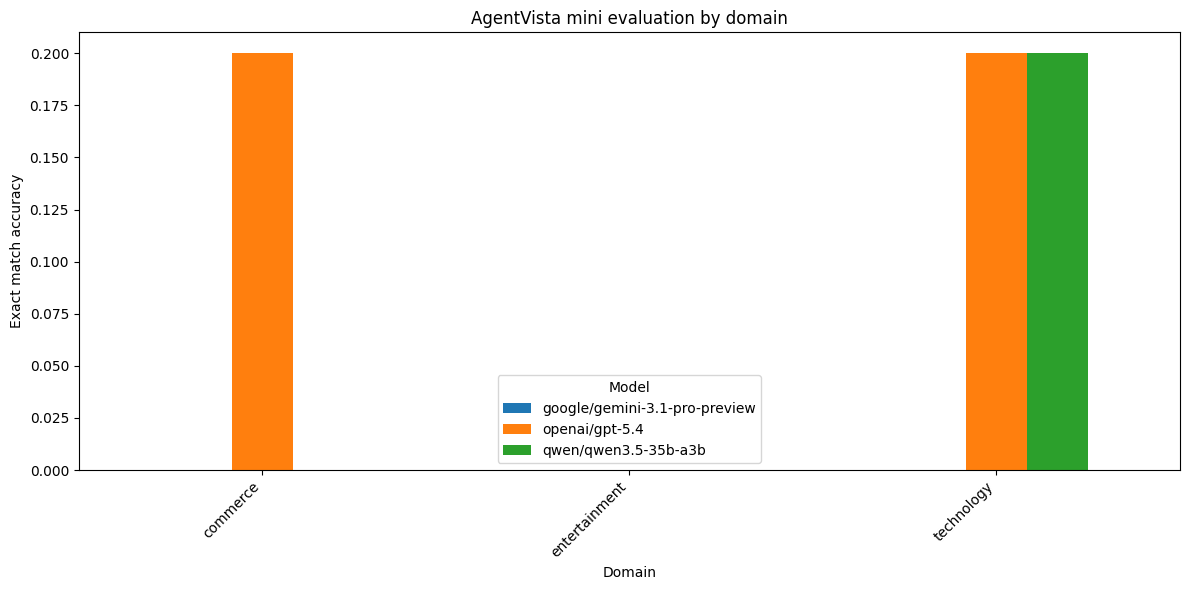

In [ ]:
# @title Plot per domain accuracy by model
import matplotlib.pyplot as plt

domain_summary = (
    results_df.groupby(["model", domain_col], as_index=False)["accuracy_binary"]
    .mean()
)

pivot_domain = domain_summary.pivot(index=domain_col, columns="model", values="accuracy_binary")
display(pivot_domain)

ax = pivot_domain.plot(kind="bar", figsize=(12, 6))
ax.set_title("AgentVista mini evaluation by domain")
ax.set_xlabel("Domain")
ax.set_ylabel("Exact match accuracy")
ax.legend(title="Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,model,accuracy_binary
1,openai/gpt-5.4,0.133333
2,qwen/qwen3.5-35b-a3b,0.066667
0,google/gemini-3.1-pro-preview,0.000000


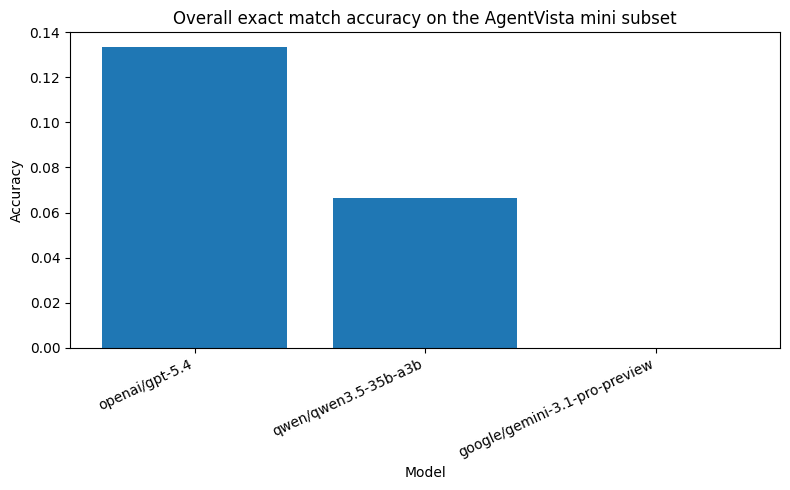

In [ ]:
# @title Plot overall accuracy by model
import matplotlib.pyplot as plt

overall = (
    results_df.groupby("model", as_index=False)["accuracy_binary"]
    .mean()
    .sort_values("accuracy_binary", ascending=False)
)

display(overall)

plt.figure(figsize=(8, 5))
plt.bar(overall["model"], overall["accuracy_binary"])
plt.title("Overall exact match accuracy on the AgentVista mini subset")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# @title Show how to extend the schema with your own use case data
import json

custom_example = [
    {
        "question_id": "custom_001",
        "question": "Look at the screenshot and identify whether the shown product matches the requested specification. Then verify the latest price online and answer with the exact product name and price.",
        "images": ["custom_images/product_case_1.png"],
        "solution": "Example Ground Truth",
        "answer": "Example Ground Truth",
        "domain": "commerce",
        "subdomain": "product_matching"
    },
    {
        "question_id": "custom_002",
        "question": "Inspect the dashboard screenshot, identify the failed component, and verify the vendor documentation for the correct remediation step.",
        "images": ["custom_images/ops_case_1.png"],
        "solution": "Restart the ingestion connector and revalidate the schema mapping",
        "answer": "Restart the ingestion connector and revalidate the schema mapping",
        "domain": "technology",
        "subdomain": "troubleshooting"
    }
]

print(json.dumps(custom_example, indent=2, ensure_ascii=False))

[
  {
    "question_id": "custom_001",
    "question": "Look at the screenshot and identify whether the shown product matches the requested specification. Then verify the latest price online and answer with the exact product name and price.",
    "images": [
      "custom_images/product_case_1.png"
    ],
    "solution": "Example Ground Truth",
    "answer": "Example Ground Truth",
    "domain": "commerce",
    "subdomain": "product_matching"
  },
  {
    "question_id": "custom_002",
    "question": "Inspect the dashboard screenshot, identify the failed component, and verify the vendor documentation for the correct remediation step.",
    "images": [
      "custom_images/ops_case_1.png"
    ],
    "solution": "Restart the ingestion connector and revalidate the schema mapping",
    "answer": "Restart the ingestion connector and revalidate the schema mapping",
    "domain": "technology",
    "subdomain": "troubleshooting"
  }
]
